<a href="https://colab.research.google.com/github/VALESOLCORTEZ/ABP-M-dulo-Analista-de-Datos-1/blob/main/Clase_4_(COM_B)_Curaci%C3%B3n_y_Tipos_b%C3%A1sicos_de_gr%C3%A1ficos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Curación y Tipos básicos de gráficos

Modulo: Analista de Datos I

Materia: Procesamiento de Datos



# 0. Importar librerías

In [ ]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn

seaborn.set_context('talk')

# 1. Cargar los datos

En esta notebook, trabajaremos con la encuesta de Sysarmy sobre salarios de programadores argentinos de 2026. Se trata de una encuesta personal y voluntaria que busca relevar información sobre salarios y condiciones de trabajo de programadores, que se realiza anualmente. Hemos limpiado un poco los datos y los colocamos en el siguiente link

https://docs.google.com/spreadsheets/d/1dBjZM_uY38bxO2nxSQmeQYPia7elJFxrCg8Ap2M_jZE/edit?gid=1573075392#gid=1573075392

**Más información sobre el conjunto de datos** https://sysarmy.com/blog/posts/resultados-de-la-encuesta-de-sueldos-2026-1/

**Fuente original de los datos**: https://docs.google.com/spreadsheets/d/1PBQxpX3jQtuD92N9BcJtYxzCtPgyY3Y90bVBFPKbUmY/edit?gid=1573075392#gid=1573075392

Para analizar los resultados podés bajar el .csv (Archivo > Descargar)
        
Recordá calificar a la empresa donde estás trabajando en www.openqube.io
Para usar el GPT (hay que hacer login aunque sea con una cuenta gratuita): https://sysar.my/sueldosgpt

Esta obra está bajo una Licencia Creative Commons Atribución-NoComercial-CompartirIgual 4.0 Internacional.

In [ ]:
url = f'https://docs.google.com/spreadsheets/d/1dBjZM_uY38bxO2nxSQmeQYPia7elJFxrCg8Ap2M_jZE/export?format=csv&gid=1573075392'
df = pd.read_csv(url)

print(df.shape)
df.head()

(4939, 60)


,donde_estas_trabajando,dedicacion,tipo_de_contrato,ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos,ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos,pagos_en_dolares,si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron,recibis_algun_tipo_de_bono,a_que_esta_atado_el_bono,tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre,...,cuanto_cobras_por_guardia,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,tengo_edad,genero,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,cuales_consideras_que_son_las_mejores_empresas_de_it_para_trabajar_en_este_momento_en_tu_ciudad,sueldo_dolarizado,seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0
3,Ciudad Autónoma de Buenos Aires,Full-Time,Staff (planta permanente),7800000.0,6000000.0,Cobro parte del salario en dólares,1470,3+ sueldos,Mix de las anteriores,No,...,NaN,NaN,NaN,60,Hombre Cis,Sí,NaN,True,Senior,7800000.0
4,Jujuy,Full-Time,Contractor,3500000.0,3200000.0,Cobro todo el salario en dólares,NaN,No,No recibo bono,No,...,NaN,NaN,NaN,29,Hombre Cis,Sí,Nose,True,Semi-Senior,3500000.0


In [ ]:
# con df.columns mostramos los nombres de todas las columnas de un DataFrame.
df.columns

Index(['donde_estas_trabajando', 'dedicacion', 'tipo_de_contrato',
       'ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos',
       'ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos',
       'pagos_en_dolares',
       'si_tu_sueldo_esta_dolarizado_cual_fue_el_ultimo_valor_del_dolar_que_tomaron',
       'recibis_algun_tipo_de_bono', 'a_que_esta_atado_el_bono',
       'tuviste_actualizaciones_de_tus_ingresos_laborales_durante_el_ultimo_semestre',
       'de_que_fue_el_ajuste_total_acumulado',
       'en_que_mes_fue_el_ultimo_ajuste',
       'como_consideras_que_estan_tus_ingresos_laborales_comparados_con_el_semestre_anterior',
       'contas_con_beneficios_adicionales',
       'que_tan_conforme_estas_con_tus_ingresos_laborales',
       'estas_buscando_trabajo', 'pluriempleo', 'trabajo_de',
       'anos_de_experiencia', 'antiguedad_en_la_empresa_actual',
       'anos_en_el_puesto_actual', 'cuantas_personas_tenes_a_cargo',
       'plataformas_que_utilizas_en_tu_puesto_act

# 2. Seleccionar nuestra variable objetivo

Antes de explorar un dataset, es fundamental definir claramente qué problema queremos resolver e identificar cuáles son las variables relevantes para ese problema. Sin esta definición previa, corremos el riesgo de perdernos en los datos sin un rumbo claro.

En este caso, elegimos pregunta de investigación es:

**¿Existe una brecha salarial por género?** Para esto, queremos comparar la distribución de salarios entre distintos géneros controlando por variables relevantes.


Para responder correctamente esta pregunta de investigación, no alcanza con comparar los salarios de hombres y mujeres directamente. Si lo hiciéramos así, estaríamos asumiendo que ambos grupos son comparables en todo lo demás, lo cual puede no ser cierto. Por ejemplo, si en la muestra hay proporcionalmente más hombres en roles senior o con gente a cargo, una diferencia salarial podría explicarse por esa disparidad y no necesariamente por el género. A esto se lo conoce como **variable de confusión**: una variable que está relacionada tanto con el género como con el salario, y que si no se controla, puede llevarnos a conclusiones erróneas.

Las **variables de control** más relevantes en este caso serían:

- **Seniority / Años de experiencia**: A mayor experiencia, mayor salario esperado. Si un grupo tiene en promedio más años de experiencia, naturalmente tendrá salarios más altos.
- **Dedicación (full time vs. part time)**: Alguien que trabaja part time va a ganar menos independientemente de su género. Comparar sin filtrar por dedicación mezcla situaciones laborales incomparables.
- **Rol y responsabilidades (gente a cargo)**: Tener personal a cargo suele estar asociado a posiciones de liderazgo y salarios más altos. Si un género está subrepresentado en esos roles, el promedio salarial se verá afectado.

El análisis correcto consiste en **comparar grupos que sean equivalentes** en estas variables, o bien modelar el efecto del género *controlando* estadísticamente por ellas. Solo así podemos aislar si el género en sí mismo tiene un efecto sobre el salario, o si las diferencias observadas se explican por otras razones.


# 3. Exploración y Limpieza de datos

## Seleccionar columnas

En base al análisis anterior, podemos filtrar sólo las columnas que nos interesan y descartar el resto. Sin embargo, esto no implica "casarse" con este filtro, sino que se puede volver sobre él para afinar el análisis. Por ejemplo, una variable que es probablemente muy relevante es si el salario está dolarizado

In [ ]:
# listamos los nombres de la columnas relevantes y las guardamos dentro de una variable.
relevant_columns = [
    'ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos',
    'ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos',
    'genero',
    'dedicacion',
    'cuantas_personas_tenes_a_cargo',
    'anos_de_experiencia'
]

In [ ]:
# visualizamos nuevamente el dataframe con las columnas relevantes
df = df[relevant_columns]
df

,ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos,ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos,genero,dedicacion,cuantas_personas_tenes_a_cargo,anos_de_experiencia
0,3000000.0,2400000.0,Mujer Cis,Full-Time,0,15
1,5000000.0,5000000.0,Mujer Cis,Full-Time,1,25
2,4600000.0,3600000.0,Mujer Cis,Full-Time,0,7
3,7800000.0,6000000.0,Hombre Cis,Full-Time,80,25
4,3500000.0,3200000.0,Hombre Cis,Full-Time,1,3
...,...,...,...,...,...,...
4934,4997000.0,3740000.0,Mujer Cis,Full-Time,0,17
4935,1100000.0,1000000.0,Hombre Cis,Full-Time,0,0
4936,3630000.0,2908000.0,Hombre Cis,Full-Time,8,3
4937,4200000.0,3400000.0,Hombre Cis,Full-Time,0,15


## Renombrar columnas
Vamos a renombrar algunas columnas para trabajar más cómodamente con el dataset

In [ ]:
df = df.rename(
    columns={
        'ultimo_salario_mensual_o_retiro_bruto_en_pesos_argentinos': 'salario_bruto',
        'ultimo_salario_mensual_o_retiro_neto_en_pesos_argentinos': 'salario_neto',
        'cuantas_personas_tenes_a_cargo': 'personas_a_cargo'
    }
)
df.head()

,salario_bruto,salario_neto,genero,dedicacion,personas_a_cargo,anos_de_experiencia
0,3000000.0,2400000.0,Mujer Cis,Full-Time,0,15
1,5000000.0,5000000.0,Mujer Cis,Full-Time,1,25
2,4600000.0,3600000.0,Mujer Cis,Full-Time,0,7
3,7800000.0,6000000.0,Hombre Cis,Full-Time,80,25
4,3500000.0,3200000.0,Hombre Cis,Full-Time,1,3


In [ ]:
# Con "df['salario_bruto'].describe()"" --> Calculamos las estadísticas descriptivas de la columna salario_bruto.
# Con "".apply(lambda s: '{0:.2f}'.format(s))" --> Aplica una función a cada valor del resultado anterior para formatearlo con 2 decimales.

df['salario_bruto'].describe().apply(lambda s: '{0:.2f}'.format(s))

,salario_bruto
count,4939.00
mean,3876029.08
std,2492699.24
min,200000.00
25%,2166335.67
50%,3268000.00
75%,4944960.00
max,20000000.00


In [ ]:
# Hacemos lo mismo con el salario neto
df['salario_neto'].describe().apply(lambda s: '{0:.2f}'.format(s))

,salario_neto
count,4717.00
mean,3599215.31
std,11837545.25
min,1.60
25%,1850000.00
50%,2750000.00
75%,4000000.00
max,653388190.00


Analicemos cómo es la distribución del dataset por género

In [ ]:
# Con el metodo "groupby("genero")"" --> Agrupamos todas las filas del DataFrame según el valor de la columna genero.
# Con "[["salario_neto"]]" --> Seleccionamos únicamente la columna salario_neto para el cálculo.
# Con ".count()" --> Contamos la cantidad de valores no nulos de salario_neto dentro de cada grupo.

df.groupby("genero")[['salario_neto']].count()

,salario_neto
genero,
Agénero,1
Hombre Cis,3688
Mujer Cis,938
No binarie,22
Prefiero no decir,49
Queer,10
Trans,8


In [ ]:
# Hacemos lo mismo para agrupar por género, pero en este caso pedimos la media del salario neto y bruto.
# Como se ve en el ejemplo se pueden mostrar las columnas que sean necesarias para visualizar.

df.groupby("genero")[['salario_neto', 'salario_bruto']].mean()

,salario_neto,salario_bruto
genero,,
Agénero,2.075191e+06,2.521440e+06
Hombre Cis,3.797298e+06,4.039036e+06
Mujer Cis,2.848352e+06,3.240928e+06
No binarie,2.275042e+06,2.850500e+06
Prefiero no decir,3.958063e+06,4.472101e+06
Queer,2.872917e+06,3.227267e+06
Trans,2.901028e+06,3.234582e+06


## Decisiones de diseño


Para cada variable relevante a nuestra pregunta de investigación, es necesario realizar un **análisis individual de su distribución** antes de proceder con cualquier comparación o modelo. Este proceso de curación implica tomar una serie de decisiones explícitas y justificadas: primero, evaluar si nos quedamos con todas las filas o si **filtramos** algún subconjunto (por ejemplo, quedarnos solo con empleados full time si es relevante para nuestra pregunta de investigación).

Segundo, decidir cómo tratar los **valores extremos**: si los removemos usando alguno de los criterios que veremos más adelante, o si los conservamos porque son valores reales y válidos dentro del contexto del problema.

Tercero, definir qué hacer con los **valores faltantes (NaN)**: podemos eliminar las filas que los contienen (`dropna`), rellenar con la media o mediana si la variable es numérica, o rellenar con la moda si es categórica.

No existe una decisión universalmente correcta, lo importante es que cada elección sea **consciente, documentada y coherente** con la pregunta de investigación, ya que estas decisiones afectan directamente los resultados del análisis.

Aquí van algunos ejemplos:


Descartar todas las filas donde los valores de salario sean nulos, ya que no suman información a nuestro análisis

In [ ]:
# sumamos la cantidad de registros donde el salario bruto es nulo
print('Registros donde el salario bruto es nulo', df['salario_bruto'].isnull().sum())

# sumamos la cantidad de registros donde el salario neto es nulo
print('Registros donde el salario neto es nulo', df['salario_neto'].isnull().sum())

df.shape

Registros donde el salario bruto es nulo 0
Registros donde el salario neto es nulo 222


(4939, 6)

In [ ]:
# Vamoa a proceder a eliminar las filas donde el salario_neto es nulo
# La funcion "df.salario_neto.isnull()" genera una serie booleana, donde
        # True = el valor de salario_neto es nulo (NaN)
        # False = el valor tiene un dato válido
# Luego el operador ~ invierte los valores para que nos quedemos con los datos válidos

df = df[~df.salario_neto.isnull()]
df.shape

(4717, 6)

In [ ]:
# Hacemos la prueba para ver si quedaron datos nulos
# sumamos la cantidad de registros donde el salario bruto es nulo
print('Registros donde el salario bruto es nulo', df['salario_bruto'].isnull().sum())

# sumamos la cantidad de registros donde el salario neto es nulo
print('Registros donde el salario neto es nulo', df['salario_neto'].isnull().sum())

Registros donde el salario bruto es nulo 0
Registros donde el salario neto es nulo 0


Limitar el análisis a las columnas "Varón Cis" y "Mujer Cis", no porque no consideremos el resto importante, sino que dada la baja cantidad de registros necesitan un tratamiento estadístico especial

In [ ]:
# Filtra el DataFrame para conservar únicamente las filas donde la columna genero sea "Hombre Cis" o "Mujer Cis".
    # El simbolo == significa igual
    # El símbolo | significa OR lógico ("o").

df = df[(df.genero == 'Hombre Cis') | (df.genero == 'Mujer Cis')]
df.shape

(4626, 6)

Descartar las filas que correspondan a trabajo part time

In [ ]:
# Vamos a aplicar nuevamente el método groupby para ver si la ocupación es Full o Part Time. Aplicamos la función contar.
df.groupby('dedicacion').count()

,salario_bruto,salario_neto,genero,personas_a_cargo,anos_de_experiencia
dedicacion,,,,,
Full-Time,4430,4430,4430,4430,4430
Part-Time,196,196,196,196,196


In [ ]:
# Filtramos el dataframe por full time, y con el shape podemos ver la cantidad de registros resultantes.
df = df[df.dedicacion == 'Full-Time']
df.shape

(4430, 6)

## Sumando visualizaciones básicas

Los estadísticos de tendencia central (media, mediana, moda) y de dispersión (desvío estándar, rango) nos dan un resumen numérico útil, pero muchas veces insuficiente para entender la distribución real de nuestros datos. Dos datasets pueden tener exactamente la misma media y el mismo desvío estándar, y sin embargo tener formas completamente distintas. Para ver cómo se distribuyen los valores, necesitamos visualizarlos.

Un histograma es un gráfico de barras donde el eje horizontal representa el rango de valores de una variable, dividido en intervalos iguales llamados bins, y el eje vertical representa la frecuencia (o cantidad de observaciones) que caen dentro de cada intervalo. A diferencia de un gráfico de barras clásico, las barras están pegadas entre sí, reflejando que la variable es continua. El histograma nos permite ver de un vistazo si la distribución es simétrica o asimétrica, si tiene un pico o varios, y si existen valores extremos (outliers) alejados del resto.

HISTOGRAMA DE SALARIO BRUTO

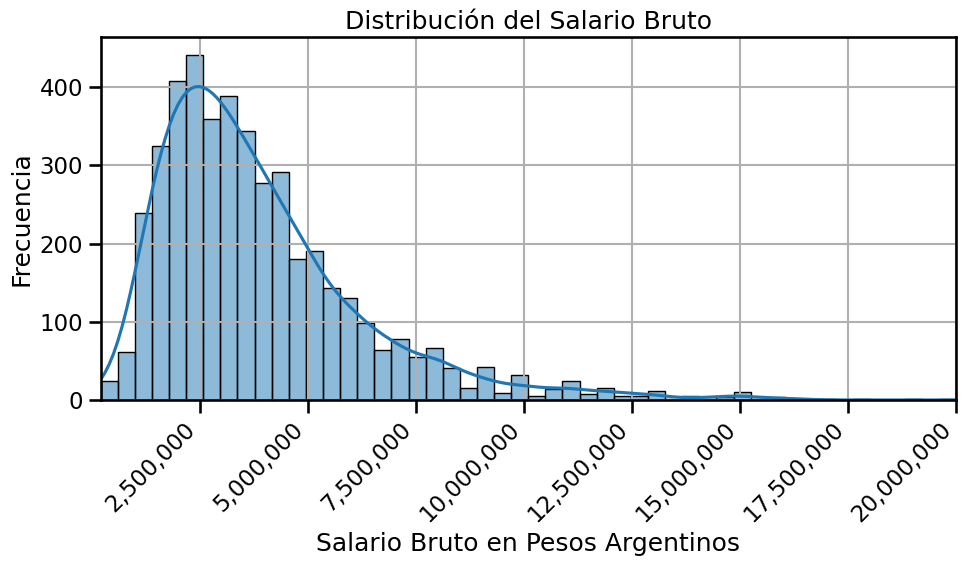

In [ ]:
# indica el tamano del histograma (10 pulgadas de ancho y 6 punpagas de alto)
plt.figure(figsize=(10, 6))

# Dibuja el histograma de la columna de salario bruto donde:
      # bins=50: divide los salarios en 50 intervalos (clases).
      # kde=True: agrega una curva suavizada de densidad (Kernel Density Estimation) para visualizar mejor la forma de la distribución.
seaborn.histplot(df['salario_bruto'], bins=50, kde=True)

# Título del gráfico
plt.title('Distribución del Salario Bruto')

# Etiqueta eje X
plt.xlabel('Salario Bruto en Pesos Argentinos')

# Etiqueta eje Y
plt.ylabel('Frecuencia')

#vLímites del eje X. Hace que el eje X vaya exactamente:
      # desde el salario mínimo observado
      # hasta el salario máximo observado
plt.xlim(df['salario_bruto'].min(), df['salario_bruto'].max())

# Activa líneas de referencia para facilitar la lectura.
plt.grid(True)

# Formato de números del eje X
      # plt.gca() Obtiene el eje actual.
      # set_major_formatter() Define cómo mostrar los números del eje X.
      # lambda x, _: f'{int(x):,}' Transforma números como: 1000000 en 1,000,000 y esto evita que Matplotlib use notación científica.
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Evitar notacion cientifica

# Rotación de etiquetas
      # gira las etiquetas 45°
      # las alinea a la derecha
plt.xticks(rotation=45, ha='right')

# Ajustar márgenes: ajusta automáticamente espacios y márgenes para que nada quede cortado.
plt.tight_layout()

# Muestra el gráfico
plt.show()

HISTOGRAMA DE SALARIO NETO

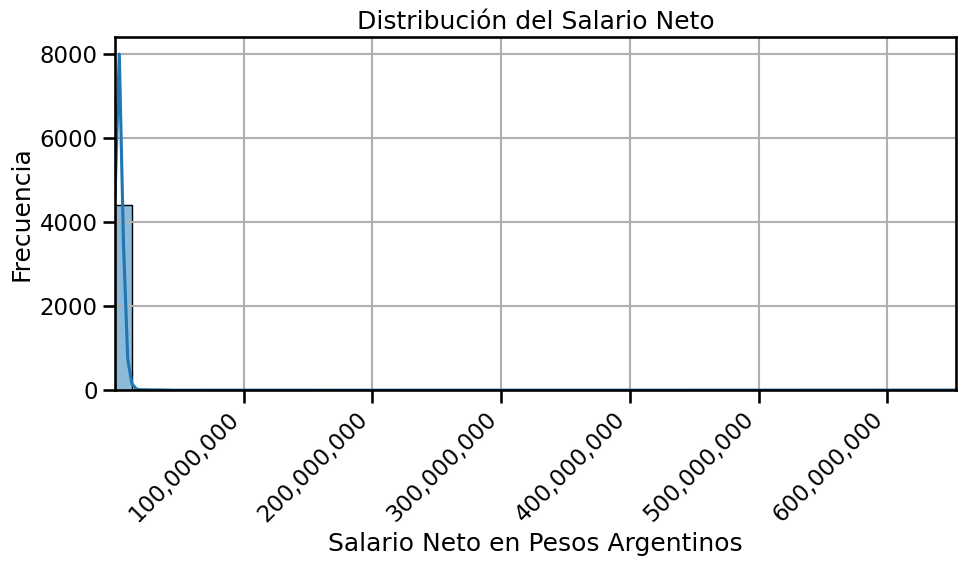

In [ ]:
plt.figure(figsize=(10, 6))

seaborn.histplot(df['salario_neto'], bins=50, kde=True)

plt.title('Distribución del Salario Neto')
plt.xlabel('Salario Neto en Pesos Argentinos')
plt.ylabel('Frecuencia')
plt.xlim(df['salario_neto'].min(), df['salario_neto'].max())

plt.grid(True)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Evitar notacion cientifica
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

¿Por qué este segundo gráfico se ve tan diferentes?

## Identificación de valores extremos


Tanto los histogramas como las medidas de tendencia central son muy sensibles a la presencia de **valores extremos u outliers**. En el caso de la media, un único valor muy alto puede desplazarla significativamente hacia arriba, dando una imagen distorsionada del salario "típico". En el histograma, los outliers comprimen todas las barras hacia la izquierda, haciendo casi imposible ver la distribución real de la mayoría de los datos, que es exactamente lo que vimos en nuestro gráfico. Para identificarlos existen varias estrategias:

- **Rango intercuartílico (IQR)** — Se calcula la distancia entre el percentil 75 y el percentil 25. Cualquier valor que caiga por debajo de `Q1 - 1.5*IQR` o por encima de `Q3 + 1.5*IQR` se considera outlier. Es el método más robusto y el que usa internamente el boxplot.
- **Regla de los 3 desvíos estándar (Z-score)** — Se consideran outliers los valores que se alejan más de 3 desvíos estándar de la media. Es menos robusto que el IQR porque tanto la media como el desvío estándar son en sí mismos sensibles a los outliers.
- **Inspección visual** — El boxplot muestra los outliers como puntos individuales fuera de los bigotes, y el histograma puede revelar barras aisladas muy a la derecha o izquierda de la distribución principal.
- **Percentiles** — Simplemente observar los valores en los extremos (por ejemplo el percentil 1 y el 99) para decidir si tienen sentido en el contexto del problema.

En datos de salarios, es especialmente importante distinguir entre outliers que son **errores de carga** (por ejemplo, un salario en dólares mezclado con salarios en pesos) y outliers que son **valores reales pero excepcionales** (por ejemplo, un CTO con un sueldo muy por encima del mercado), ya que cada caso requiere un tratamiento distinto.

### Rango itercuartílico

In [ ]:
Q1 = df['salario_neto'].quantile(0.25)
Q3 = df['salario_neto'].quantile(0.75)
IQR = Q3 - Q1

df_sin_outliers_iqr = df[(df['salario_neto'] >= Q1 - 1.5 * IQR) &
                      (df['salario_neto'] <= Q3 + 1.5 * IQR)]

# La función len devuel la cantidad de elementos de un objeto. En este caso devuelve la cantidad de fila (registros)
# Si aparece un f-string, Python evalua lo que está entre llaves {} y lo inserta en el texto
print(f"Registros originales:        {len(df)}")
print(f"Registros sin outliers:      {len(df_sin_outliers_iqr)}")
print(f"Outliers removidos:          {len(df) - len(df_sin_outliers_iqr)}")

Registros originales:        4430
Registros sin outliers:      4196
Outliers removidos:          234


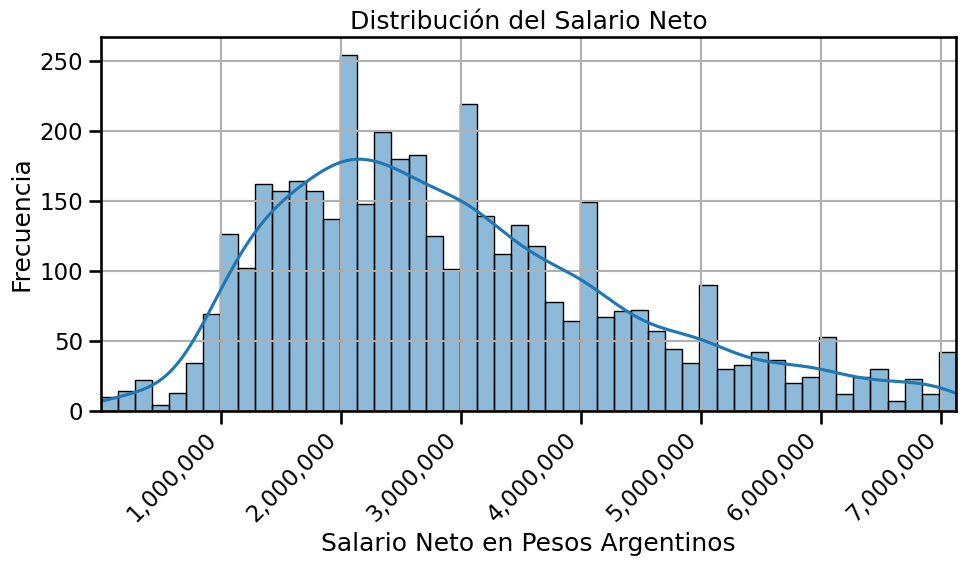

In [ ]:
# En esta sección lo que hacemos es graficar el histograma de salario sin los outliers

# indica el tamano del histograma (10 pulgadas de ancho y 6 punpagas de alto)
plt.figure(figsize=(10, 6))

# Dibuja el histograma de la columna de salario neto sin los outliers donde:
      # bins=50: divide los salarios en 50 intervalos (clases).
      # kde=True: agrega una curva suavizada de densidad (Kernel Density Estimation) para visualizar mejor la forma de la distribución.
seaborn.histplot(df_sin_outliers_iqr['salario_neto'], bins=50, kde=True)

# Título del gráfico
plt.title('Distribución del Salario Neto')

# Etiqueta eje X
plt.xlabel('Salario Neto en Pesos Argentinos')

# Etiqueta eje Y
plt.ylabel('Frecuencia')

#vLímites del eje X. Hace que el eje X vaya exactamente:
      # desde el salario mínimo observado sin outliers
      # hasta el salario máximo observado sin outliers
plt.xlim(df_sin_outliers_iqr['salario_neto'].min(), df_sin_outliers_iqr['salario_neto'].max())

# Activa líneas de referencia para facilitar la lectura.
plt.grid(True)

# Formato de números del eje X
      # plt.gca() Obtiene el eje actual.
      # set_major_formatter() Define cómo mostrar los números del eje X.
      # lambda x, _: f'{int(x):,}' Transforma números como: 1000000 en 1,000,000 y esto evita que Matplotlib use notación científica.
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Evitar notacion cientifica

# Rotación de etiquetas
      # gira las etiquetas 45°
      # las alinea a la derecha
plt.xticks(rotation=45, ha='right')

# Ajustar márgenes: ajusta automáticamente espacios y márgenes para que nada quede cortado.
plt.tight_layout()

# Muestra el gráfico
plt.show()

### Percentiles

Un percentil indica el valor por debajo del cual se encuentra un determinado porcentaje de observaciones. Si tomamos un P = 90, entonces el valor que estaría quedando afuera es el salario = 1.000. Por ejemplo:

| Posición | Salario |
| -------- | ------: |
| 1        |     100 |
| 2        |     120 |
| 3        |     150 |
| 4        |     180 |
| 5        |     200 |
| 6        |     220 |
| 7        |     250 |
| 8        |     300 |
| 9        |     400 |
| 10       |    1000 |

* **Paso 1: Calcular la posición**

    Posicion=(n−1)×p+1
    ➡️ donde: n = cantidad de datos y p = percentil expresado entre 0 y 1

    Para P90 = (10−1)×0.90+1 = 9.1
    
    La posición 9.1 está entre: posición 9 (salario 400) y posición 10 (salario 1000)

* **Paso 2: Interpolar**

  La diferencia entre ambos salarios es: 1000−400=600

  Tomamos el 10% de esa diferencia porque estamos en la posición 9.1 ➡️ P90 = 400+0.1×600 = 400+60 = 460

  **Interpretación. El percentil 90 es aproximadamente: P90=460. Esto significa que el 90% de los salarios son menores o iguales a 460 y el 10% son mayores.**

Para nuestro siguiente ejemplo:

"Un percentil divide una distribución ordenada en 100 partes. El percentil 98 representa el valor por debajo del cual se encuentra el 99% de los datos.
En nuestro análisis calculamos el P1 y el P99 para eliminar los valores extremos, conservando el 98% central de las observaciones y reduciendo la influencia de outliers sobre los resultados."

In [ ]:
P1 = df['salario_neto'].quantile(0.01)
P99 = df['salario_neto'].quantile(0.99)

# Conserva únicamente los salarios:
      # mayores o iguales al percentil 1
      # menores o iguales al percentil 99
# Dicho de otra forma, ELIMINA:
      # el 1% más bajo
      # el 1% más alto
df_sin_outliers_perc = df[(df['salario_neto'] >= P1) &
                     (df['salario_neto'] <= P99)]

# La función len devuel la cantidad de elementos de un objeto. En este caso devuelve la cantidad de fila (registros)
# Si aparece un f-string, Python evalua lo que está entre llaves {} y lo inserta en el texto
print(f"Registros originales:        {len(df)}")
print(f"Registros sin outliers:      {len(df_sin_outliers_perc)}")
print(f"Outliers removidos:          {len(df) - len(df_sin_outliers_perc)}")

Registros originales:        4430
Registros sin outliers:      4345
Outliers removidos:          85


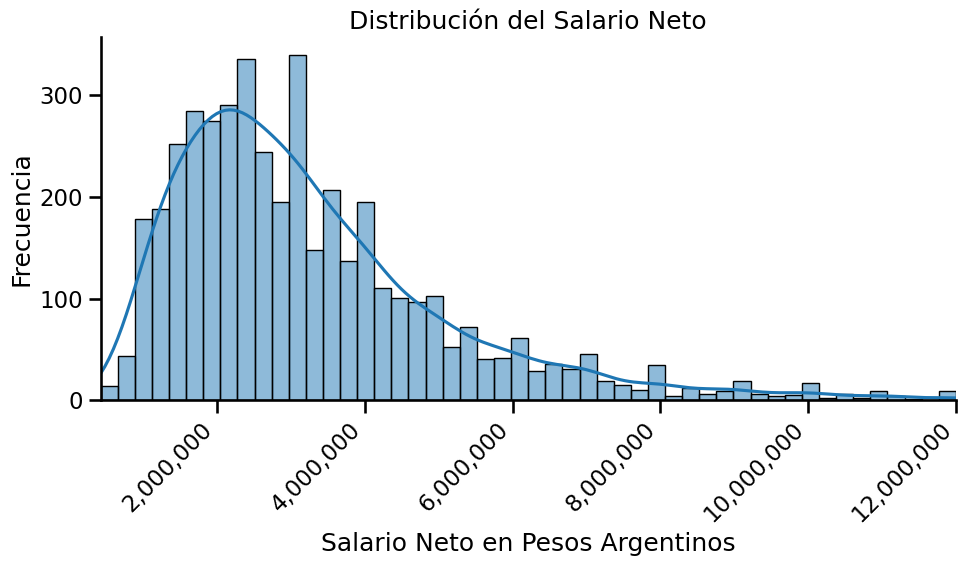

In [ ]:
# Graficamos el histograma sin estos valores extremos
plt.figure(figsize=(10, 6))

seaborn.histplot(df_sin_outliers_perc['salario_neto'], bins=50, kde=True)

plt.title('Distribución del Salario Neto')
plt.xlabel('Salario Neto en Pesos Argentinos')
plt.ylabel('Frecuencia')
plt.xlim(df_sin_outliers_perc['salario_neto'].min(), df_sin_outliers_perc['salario_neto'].max())

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Evitar notacion cientifica
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
seaborn.despine()
plt.show()

### ZScores

¿Dónde aparece el Z-Score?
La formula tradicional es:

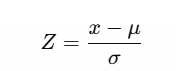

Donde:
* x = salario
* μ = media
* σ = desvío estándar


Un dato suele considerarse outlier cuando:

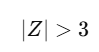

Es decir

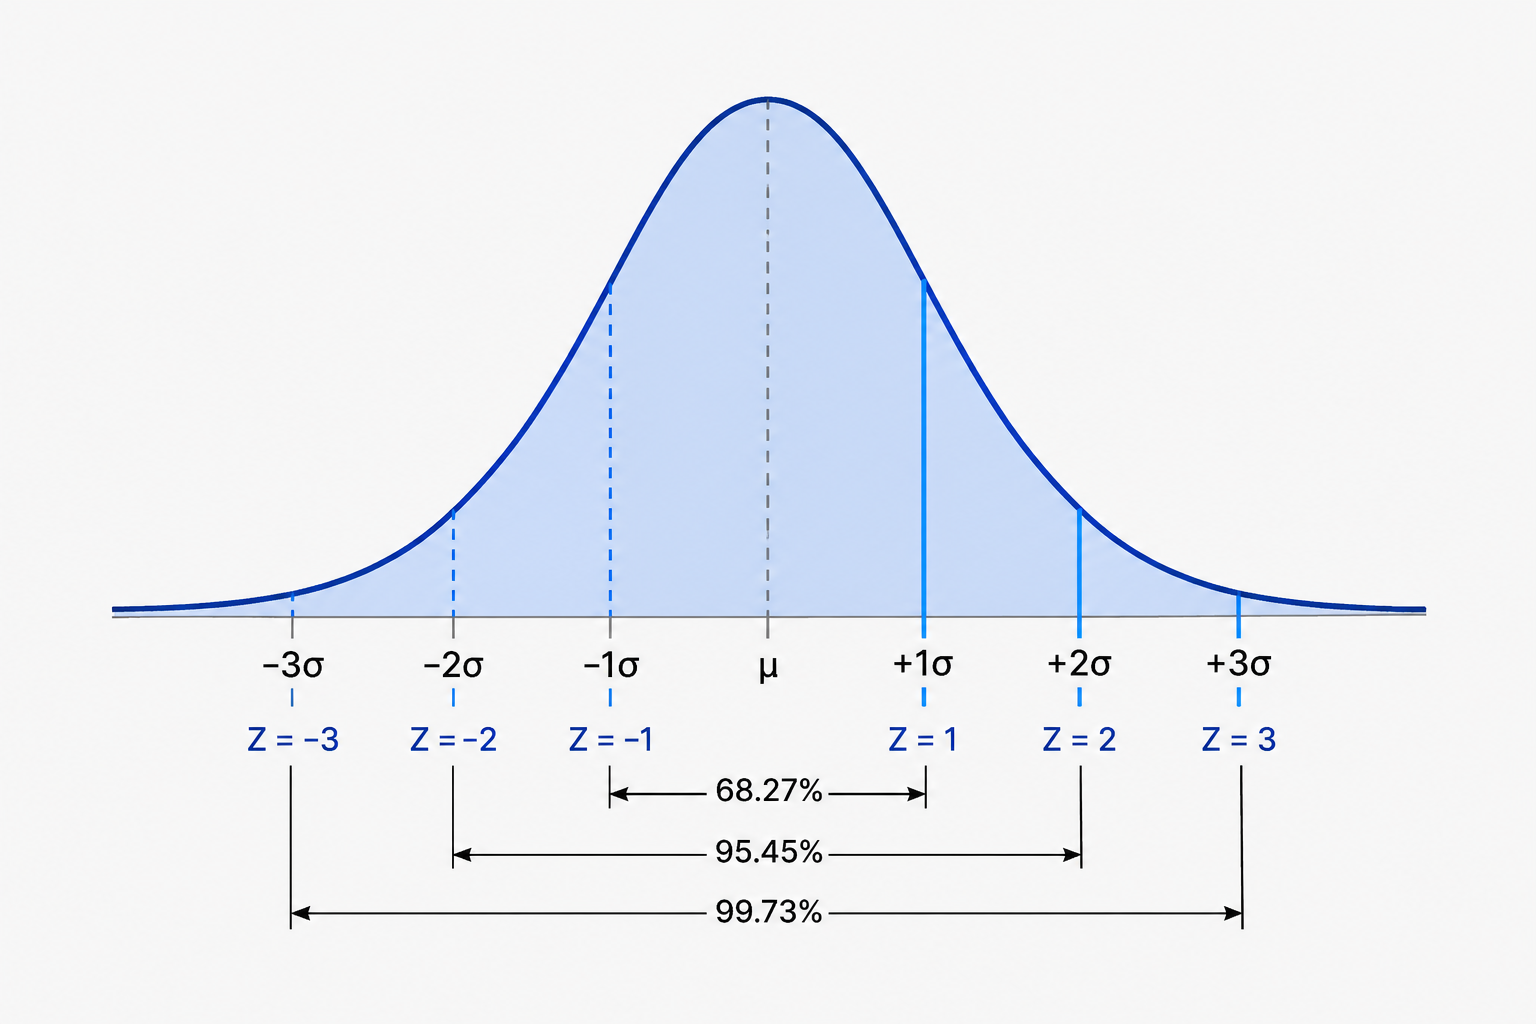




In [ ]:
media = df['salario_neto'].mean()
desvio = df['salario_neto'].std()

df_sin_outliers_zscore = df[abs(df['salario_neto'] - media) <= 3 * desvio]

print(f"Registros originales:        {len(df)}")
print(f"Registros sin outliers:      {len(df_sin_outliers_zscore)}")
print(f"Outliers removidos:          {len(df) - len(df_sin_outliers_zscore)}")

Registros originales:        4430
Registros sin outliers:      4422
Outliers removidos:          8


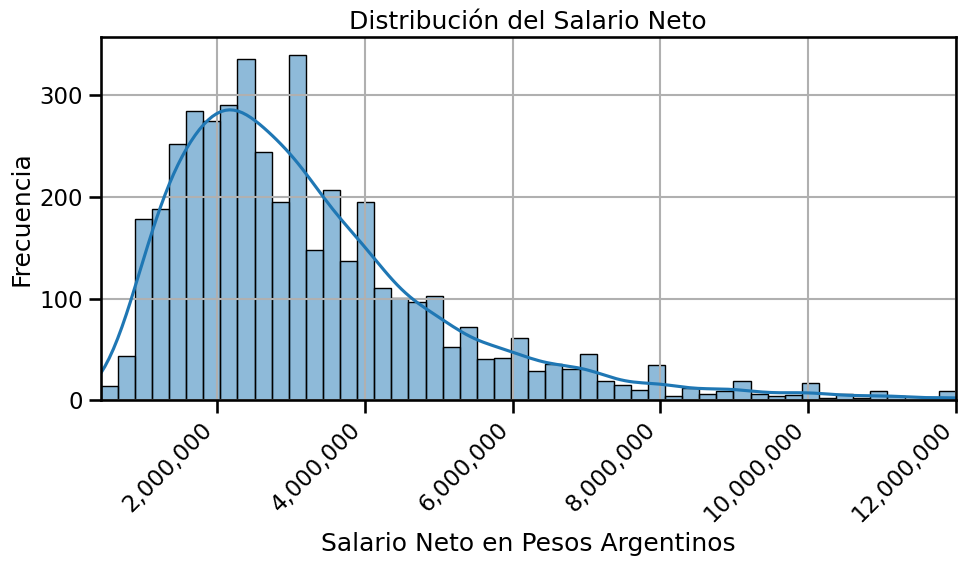

In [ ]:
plt.figure(figsize=(10, 6))

seaborn.histplot(df_sin_outliers_perc['salario_neto'], bins=50, kde=True)

plt.title('Distribución del Salario Neto')
plt.xlabel('Salario Neto en Pesos Argentinos')
plt.ylabel('Frecuencia')
plt.xlim(df_sin_outliers_perc['salario_neto'].min(), df_sin_outliers_perc['salario_neto'].max())

plt.grid(True)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}')) # Evitar notacion cientifica
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Para cuantificar la asimetría de una distribución existen varios coeficientes teóricos. El más utilizado es el **coeficiente de asimetría de Fisher**, basado en el tercer momento central estandarizado:

$$\gamma_1 = \frac{\frac{1}{n}\sum(x_i - \bar{x})^3}{\left(\sqrt{\frac{1}{n}\sum(x_i - \bar{x})^2}\right)^3}$$

Una alternativa más simple es el **segundo coeficiente de Pearson**, que reemplaza el momento central por la relación entre media, mediana y desvío estándar, siendo más robusto frente a valores extremos:

$$Sk_2 = \frac{3(\bar{x} - mediana)}{\sigma}$$

Finalmente, el **coeficiente de Bowley** es el más robusto de los tres ya que está basado enteramente en cuartiles, evitando cualquier influencia de la media o el desvío estándar:

$$Sk_B = \frac{Q_3 + Q_1 - 2Q_2}{Q_3 - Q_1}$$

En los tres casos, un valor de $0$ indica simetría, valores positivos indican una cola hacia la derecha (como es típico en distribuciones de salarios), y valores negativos indican una cola hacia la izquierda. A continuación calcularemos los tres coeficientes para nuestra variable de interés y compararemos los resultados.

In [ ]:
Q1 = df['salario_bruto'].quantile(0.25)
Q2 = df['salario_bruto'].quantile(0.50)
Q3 = df['salario_bruto'].quantile(0.75)

bowley = (Q3 + Q1 - 2 * Q2) / (Q3 - Q1)
print(f"Coeficiente de Bowley: {bowley:.4f}")

Coeficiente de Bowley: 0.1885


Probemos a ver que pasa con la distribución del salario neto, que en el histograma original aparece como mucho más asimétrica

In [ ]:
Q1 = df['salario_neto'].quantile(0.25)
Q2 = df['salario_neto'].quantile(0.50)
Q3 = df['salario_neto'].quantile(0.75)

bowley = (Q3 + Q1 - 2 * Q2) / (Q3 - Q1)
print(f"Coeficiente de Bowley: {bowley:.4f}")

Coeficiente de Bowley: 0.1443


Sería más intuitivo que el salario neto sea el más asimétrico, pero vemos que el coeficiente obtenido es menor, ¿por qué?

## Análisis de varias variables (numéricas más categóricas)

Seguimos tratando de responder a nuestra pregunta de investigación sobre la brecha salarial por género en programadores argentinos. Para ello, queremos comparar ver la distribucion de salario bruto en ambos géneros (comparamos una misma variable en dos muestras distintas).

Intentemos el primer gráfico

<Figure size 1500x600 with 0 Axes>

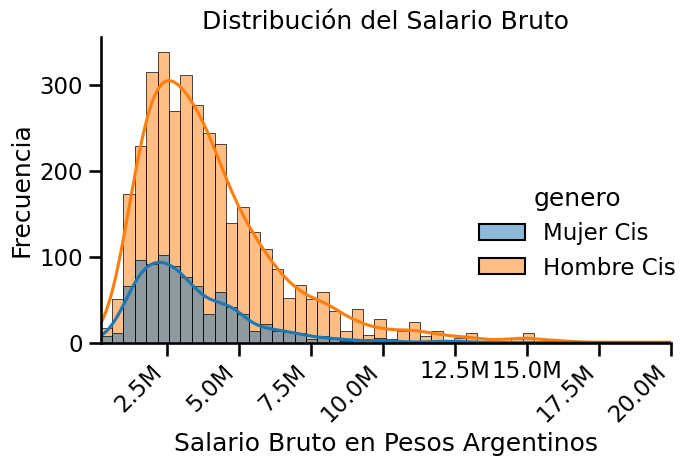

In [ ]:
plt.figure(figsize=(15, 6))

# data=df --> Utiliza el DataFrame df
# x='salario_bruto' --> La variable a analizar es salario_bruto.
# bins=50 --> Divide los salarios en 50 intervalos.
# kde=True --> Agrega una curva suavizada de densidad.
# hue='genero' --> Separa la distribución por género utilizando colores diferentes.
seaborn.displot(data=df, x='salario_bruto', bins=50, kde=True, hue="genero")

# Titulo
plt.title('Distribución del Salario Bruto')

# Etiqueta eje X
plt.xlabel('Salario Bruto en Pesos Argentinos')
# Etiqueta eje Y
plt.ylabel('Frecuencia')

# Límites del eje X: Hace que el eje horizontal vaya desde: salario mínimo a salario máximo
plt.xlim(df['salario_bruto'].min(), df['salario_bruto'].max())

# Formato de millones: de esta manera el eje es más legible cuando los salarios son grandes.
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))

# Gira las etiquetas del eje X 45 grados.
plt.xticks(rotation=45, ha='right')

# Ajuste automático
plt.tight_layout()

# Mostrar gráfico
plt.show()

¿Por qué este gráfico es poco útil para responder nuestra pregunta de investigación?

En el gráfico anterior, las barras de los hombres dominaban visualmente porque tenían mayor frecuencia absoluta.

En el siguiente gráfico vamos a trabajar con una densidad normalizada (1e−7 en el eje Y), que permite comparar las formas de las distribuciones independientemente de la cantidad de observaciones.

<Figure size 1500x600 with 0 Axes>

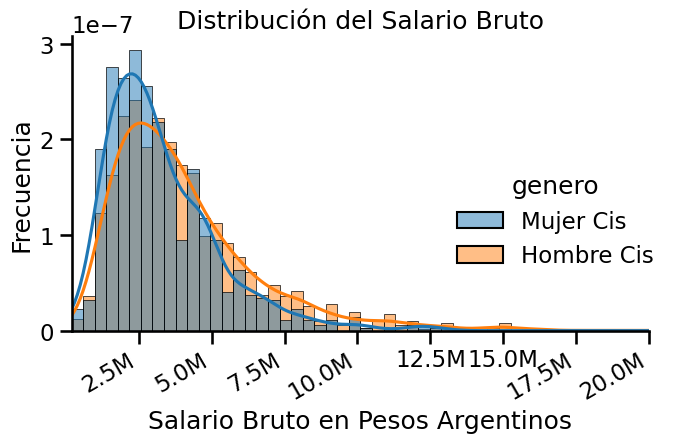

In [ ]:
plt.figure(figsize=(15, 6))

seaborn.displot(data=df, x='salario_bruto', bins=50, kde=True, hue="genero", stat="density", common_norm=False)

plt.title('Distribución del Salario Bruto')
plt.xlabel('Salario Bruto en Pesos Argentinos')
plt.ylabel('Frecuencia')
plt.xlim(df['salario_bruto'].min(), df['salario_bruto'].max())

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
plt.xticks(rotation=30, ha='right')
plt.tight_layout();

Se puede ver una leve diferencia entre las distribuciones, pero estamos llegando al límite de lo que es apreciable a través de un histograma.

Ahora se puede apreciar que:

1. La curva azul (Mujer Cis) tiene su pico más concentrado.
2. La curva naranja (Hombre Cis) está más desplazada hacia salarios superiores.
3. Los hombres presentan una cola derecha más extensa.
4. Las mujeres tienen una mayor concentración entre aproximadamente 2 y 4 millones.
5. Los hombres muestran una dispersión más amplia y una mayor presencia de salarios altos.


Tratemos algún otro gráfico de distribución que nos permita combinar una variable numérica con una categórica

### Boxplots

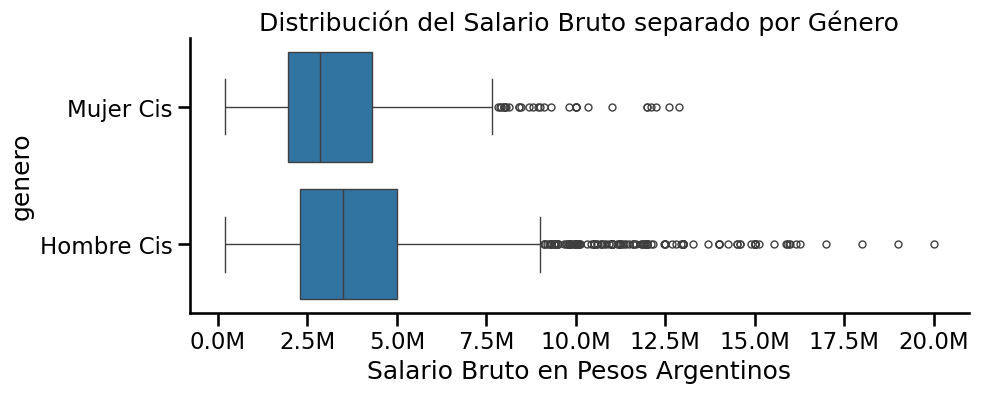

In [ ]:
# Un box plot (diagrama de caja y bigotes) es un gráfico que resume una distribución
# Primer cuartil (Q1): Valor que deja por debajo el 25% de los datos.
# Mediana (Q2): La línea dentro de la caja. Representa el valor central de los datos.
# Tercer cuartil (Q3): Valor que deja por debajo el 75% de los datos.
# Caja: va desde Q1 → Q3 y contiene el 50% central de los datos.
# Bigotes: Representan el rango normal de los datos. Generalmente llegan hasta:
        # Q1−1.5×IQR
        # Q3+1.5×IQR
        # donde: IQR=Q3−Q1
# Outliers: Los puntos que aparecen fuera de los bigotes.

# catplot() es una función de Seaborn diseñada para crear gráficos categóricos de manera sencilla.
# y='genero' La variable categórica va en el eje vertical.
# x='salario_bruto' La variable numérica a analizar es el salario bruto.
# kind="box" indica la creación de un gráfico de Box Plot
# aspect=2.5 Controla la relación ancho/alto.
# height=4 Altura del gráfico en pulgadas.
seaborn.catplot(data=df, y='genero', x='salario_bruto', kind="box", aspect=2.5, height=4)

plt.title('Distribución del Salario Bruto separado por Género')
plt.xlabel('Salario Bruto en Pesos Argentinos')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'));

¿Qué observamos?
**1. La mediana salarial es mayor en los hombres**

   Se observa que la mediana de Hombre Cis está ligeramente más a la derecha que la de Mujer Cis. Esto sugiere que el salario bruto típico de los hombres es superior al de las mujeres dentro de la muestra analizada.

**2. Los hombres presentan mayor dispersión salarial**

   La caja representa el rango intercuartílico (IQR), es decir, el 50% central de los salarios. La caja de Hombre Cis es más ancha, lo que indica mayor variabilidad en los salarios masculinos. En otras palabras, los salarios de los hombres están más dispersos.

**3. Existen muchos outliers en ambos grupos**

   Los puntos ubicados fuera de los bigotes son valores atípicos (outliers).Se observan numerosos salarios extremos en ambos géneros. Sin embargo, los hombres presentan una mayor cantidad de outliers y alcanzan valores significativamente más elevados.

**4. Los salarios máximos son mucho mayores en hombres**

   Los outliers masculinos llegan aproximadamente hasta 20 MM mientras que los femeninos alcanzan aproximadamente 13 MM.

**5. Ambas distribuciones presentan asimetría positiva**

   Los bigotes y outliers se extienden mucho más hacia la derecha que hacia la izquierda. Esto significa que la mayoría de las personas se concentra en salarios medios, mientras que existe una minoría con salarios muy altos. Es una característica típica de distribuciones salariales.

**Conclusión para el informe**

"El box plot evidencia diferencias en la distribución del salario bruto según género. La mediana salarial de los hombres resulta superior a la observada para las mujeres, mientras que la dispersión de los ingresos también es mayor en el grupo masculino. Asimismo, ambos grupos presentan una distribución asimétrica positiva con numerosos valores atípicos, aunque los hombres exhiben una mayor cantidad de salarios extremos y alcanzan niveles máximos considerablemente más elevados. Estos resultados sugieren una mayor heterogeneidad salarial dentro del grupo masculino."

¿Por qué suele ser mejor que el histograma?

| Histograma                        | Box Plot                    |
| --------------------------------- | --------------------------- |
| Muestra toda la distribución      | Resume la distribución      |
| Puede ser difícil comparar grupos | Comparación inmediata       |
| Sensible a la elección de bins    | No depende de bins          |
| Ocupa mucho espacio               | Muy compacto                |
| No muestra cuartiles claramente   | Muestra cuartiles y mediana |


Otras visualizaciones que son apropiadas para estas variables son:


### Violin plots

El violin plot es una visualización que combina dos gráficos en uno: hacia los costados muestra una estimación de la densidad de la distribución (similar a un histograma suavizado rotado), y en el centro incorpora un boxplot compacto.

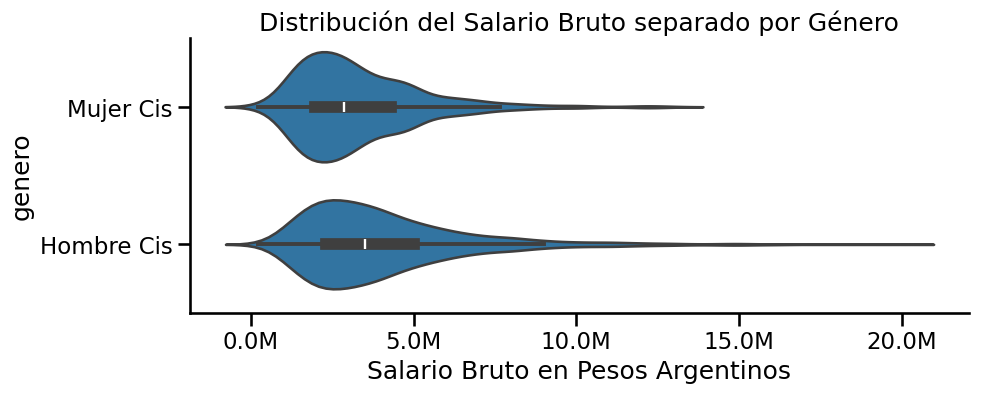

In [ ]:
seaborn.catplot(data=df, y='genero', x='salario_bruto', kind="violin", aspect=2.5, height=4)
plt.title('Distribución del Salario Bruto separado por Género')
plt.xlabel('Salario Bruto en Pesos Argentinos')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'));

Este gráfico es un violin plot y resulta más informativo que el box plot porque muestra no solo los estadísticos resumidos sino también la forma completa de la distribución.

¿Qué información extra aporta respecto al box plot?
MUESTRA DONDE SE CONCENTRAN LOS SALARIOS.

1. En un box plot solo se observa Mediana.
    Cuartiles.
    Bigotes.
    Outliers.

2. En cambio, el violin plot muestra además la densidad de los datos. La parte más ancha del violín indica donde hay más observaciones.

Por ejemplo, aquí se observa que tanto hombres como mujeres tienen una fuerte concentración aproximadamente entre 2M y 5M.


### Swarm plots

1. ***El swarm plot es una visualización que muestra cada observación individual como un punto, distribuyéndolos de manera que no se superpongan entre sí.***
A diferencia del violin plot o el boxplot, que resumen la distribución mediante estadísticos o curvas de densidad, el swarm plot preserva toda la información del dataset: cada fila es un punto visible en el gráfico. Los puntos se desplazan horizontalmente para evitar solapamientos, de forma que la densidad de puntos en cada zona refleja directamente la frecuencia de esos valores, generando una forma similar a la de un histograma rotado.

2. ***Su principal ventaja es la transparencia total:*** podemos ver exactamente cuántas observaciones hay, dónde se concentran y cuáles son los valores atípicos. Su principal limitación es que con datasets muy grandes los puntos se vuelven difíciles de distinguir y el gráfico puede volverse ilegible, por lo que es más útil cuando el número de observaciones es moderado o cuando se combina con un violin plot usando seaborn.violinplot + seaborn.swarmplot sobre el mismo eje.

En nuestro caso, para limitar el numero de elementos tomaremos una muestra del 10%

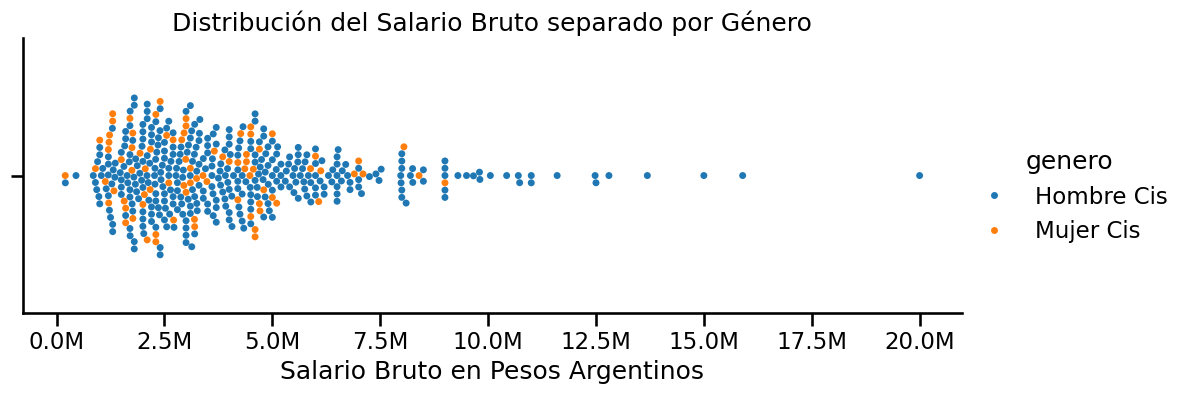

In [ ]:
df_muestra = df.sample(frac=0.1, random_state=42)

seaborn.catplot(data=df_muestra, x='salario_bruto', hue="genero", kind="swarm", aspect=2.5, height=4)
plt.title('Distribución del Salario Bruto separado por Género')
plt.xlabel('Salario Bruto en Pesos Argentinos')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'));

Al tomar una muestra del dataset para visualización es importante ser conscientes de cómo lo hacemos. El parámetro random_state controla la semilla del generador de números aleatorios: si lo fijamos en un valor (por ejemplo 42), la muestra será siempre la misma cada vez que ejecutemos el código, lo que garantiza reproducibilidad. Esto es útil cuando queremos que otros puedan replicar exactamente nuestros resultados. Si en cambio no especificamos random_state, cada ejecución seleccionará filas distintas, lo que puede generar gráficos ligeramente diferentes en cada corrida.

Más allá de la reproducibilidad, también hay que decidir si queremos que la muestra sea representativa: un 10% tomado aleatoriamente debería preservar las proporciones originales de cada género en el dataset, pero si los grupos están muy desbalanceados (por ejemplo, hay muchos más hombres que mujeres), la muestra va a heredar ese desbalance y el swarm plot seguirá mostrando muchos más puntos para un grupo que para el otro. En ese caso **podría** ser preferible hacer un muestreo estratificado, tomando una muestra de X filas de cada grupo para una representación equilibrada en el gráfico.

NOTA DE COLOR: ¿Por qué se usa tanto 42?
1. No tiene ningún significado matemático especial.
2. Se popularizó por una referencia humorística de la novela: The Hitchhiker's Guide to the Galaxy, donde 42 es "la respuesta al sentido de la vida, el universo y todo lo demás".

Otros valores comunes, todos igualmente válidos
* random_state = 0
* random_state = 1
* random_state = 7
* random_state = 42
* random_state = 123
* random_state = 2024

A diferencia del gráfico anterior, veamos que sucede cuando comparamos ambos géneros en igualdad de condiciones, tomando 100 observaciones de cada género.

/tmp/ipykernel_14039/2748542842.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n, random_state=42))  # Con ".apply" se aplicará o ejecutará una función sobre cada grupo.


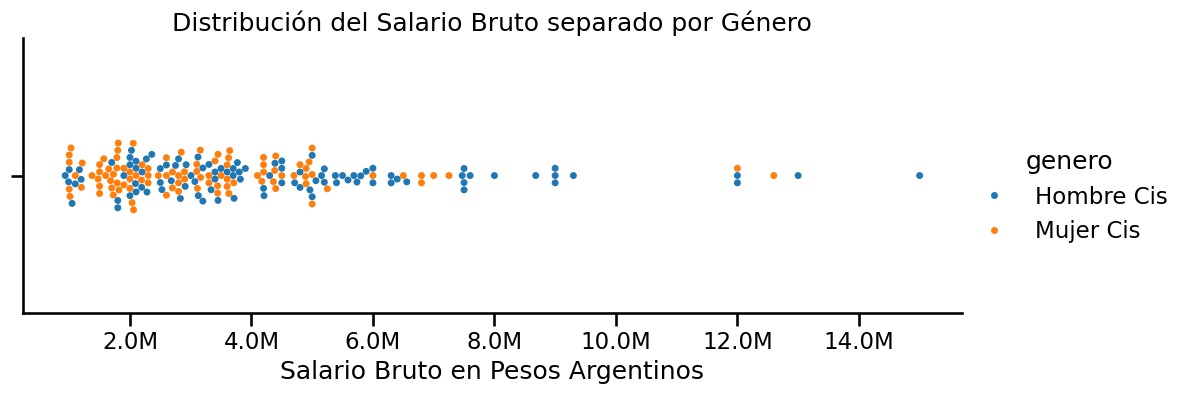

In [ ]:
# Definimos que se tomarán 100 observaciones de cada género.
# En otras palabras creamos una muestra aleatoria balanceada por género, tomando exactamente 100 registros de cada grupo.
# Guardamos el número 100 en una variable llamada n.
n = 100

df_muestra = (df.groupby('genero', group_keys=False) # Dividimos el DataFrame en grupos según la columna genero.
                .apply(lambda x: x.sample(n=n, random_state=42))  # Con ".apply" se aplicará o ejecutará una función sobre cada grupo.
                                                                  # "x" respresenta a cada grupo (recordar que sample es un método de Pandas que sirve para seleccionar filas aleatoriamente de un DataFrame o una Serie)
                                                                  # "x.sample" selecciona aleatoreamente 100 filas
                .reset_index(drop=True)) # Se utiliza para reiniciar o reconstruir el indice de un df (ver nota más abajo)

seaborn.catplot(data=df_muestra, x='salario_bruto', hue="genero", kind="swarm", aspect=2.5, height=4)
plt.title('Distribución del Salario Bruto separado por Género')
plt.xlabel('Salario Bruto en Pesos Argentinos')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'));

| Aspecto                      | Opción 1                 | Opción 2                    |
| ---------------------------- | ------------------------ | --------------------------- |
| Tipo de muestra              | Aleatoria global         | Estratificada por género    |
| Tamaño por grupo             | Proporcional al original | Igual para todos los grupos |
| Conserva proporciones reales | ✅                        | ❌                           |
| Facilita comparación visual  | ❌                        | ✅                           |
| Recomendada para Swarm Plot  | Regular                  | ✅                           |


NOTA: ¿POR QUÉ RECONSTRUIR UN INDICE?
Dijimos que reset_index() sirve para reiniciar o reconstruir el índice de un DataFrame.
Se utiliza después de un groupby() y un apply() porque esas operaciones suelen dejar índices "extraños" o jerárquicos.

Supongamos que tenemos el siguiente índice:
| índice | genero |
| ------ | ------ |
| 0      | Hombre |
| 1      | Hombre |
| 2      | Hombre |
| 3      | Mujer  |
| 4      | Mujer  |
| 5      | Mujer  |

Si aplicamos un df.sample(n=3, random_state=42) obtenemos algo como lo que sigue (se conservan los indices originales):

| índice | genero |
| ------ | ------ |
| 5      | Mujer  |
| 0      | Hombre |
| 3      | Mujer  |

Con un df.reset_index() creamos un nuevo indice consecutivo:

| índice_nuevo | índice_viejo | genero |
| ------------ | ------------ | ------ |
| 0            | 5            | Mujer  |
| 1            | 0            | Hombre |
| 2            | 3            | Mujer  |





Vemos otra forma en el que mostramos nuestros datos

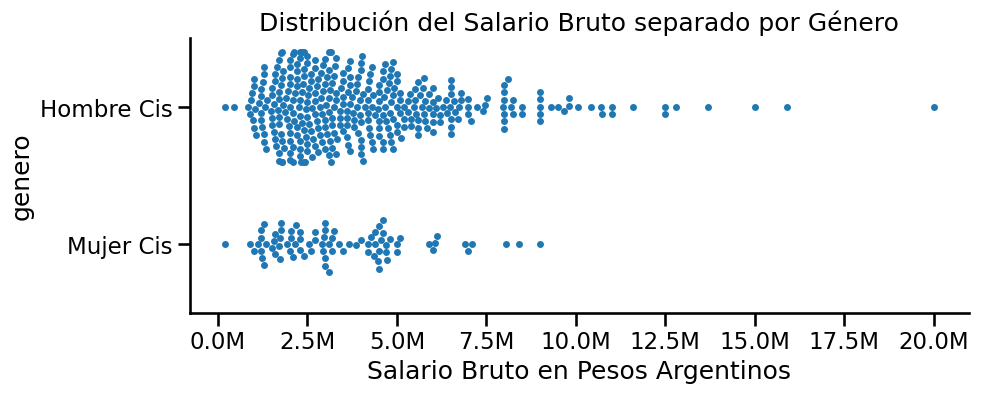

In [ ]:
df_muestra = df.sample(frac=0.1, random_state=42) #Tomamos el 10% de las filas utilizando la muestra creada anteriormente

#Aquí ponemos en el "eje y" el genero y en el "eje x" el salario bruto (abrimos el gráfico a diferencia del anterior)
seaborn.catplot(data=df_muestra, y='genero', x='salario_bruto', kind="swarm", aspect=2.5, height=4)
plt.title('Distribución del Salario Bruto separado por Género')
plt.xlabel('Salario Bruto en Pesos Argentinos')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'));

## Análisis de varias variables (numéricas)

Hasta ahora observamos que existe una diferencia en la distribución de salarios entre géneros. Sin embargo, como discutimos al inicio, no podemos concluir que esa diferencia se deba al género en sí mismo sin antes controlar por otras variables relevantes. Una de las más importantes es la experiencia laboral: es razonable esperar que a mayor antigüedad en el sector, mayor sea el salario, independientemente del género. Si por ejemplo los hombres tienen en promedio más años de experiencia que las mujeres en nuestra muestra, parte de la brecha salarial observada podría explicarse por esa diferencia y no por el género. Para explorar esta relación vamos a comenzar con un pairplot, que nos permite visualizar de forma simultánea las relaciones entre múltiples variables numéricas, mostrando un scatterplot para cada par de variables y la distribución individual de cada una en la diagonal. Esto nos dará una primera intuición sobre si existe una correlación entre experiencia y salario, y si esa relación varía según el género.

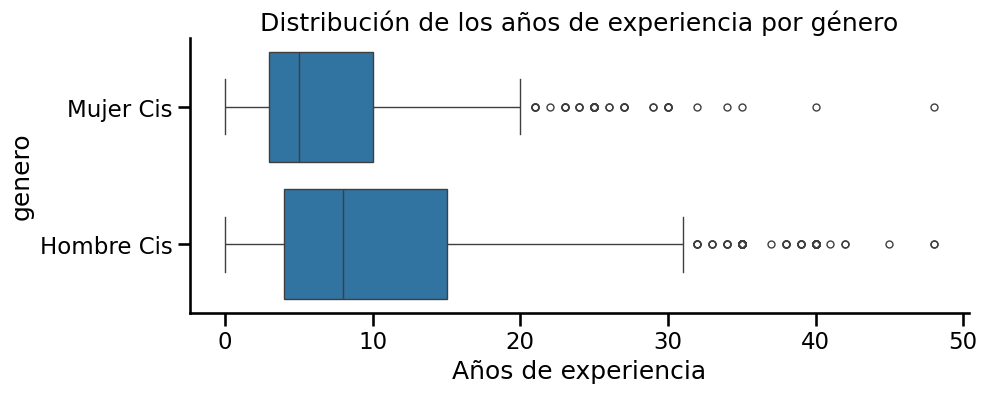

In [ ]:
# Creamos un BoxPlot dejando en el "eje y" el género y en el "eje x" los años de experiencia
seaborn.catplot(data=df, y='genero', x='anos_de_experiencia', kind="box", aspect=2.5, height=4)
plt.title('Distribución de los años de experiencia por género')
plt.xlabel('Años de experiencia')

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}'));

El **jointplot** es una visualización que combina en un único gráfico la relación entre dos variables (en el centro) junto con la distribución individual de cada una (en los márgenes). Es especialmente útil para variables **numéricas continuas**, ya que permite responder dos preguntas al mismo tiempo: ¿cómo se distribuye cada variable por separado? y ¿existe alguna relación o patrón entre ambas? En nuestro caso lo usamos para explorar la relación entre `salario_bruto` y `anos_de_experiencia` porque ambas son variables numéricas continuas y queremos entender si la experiencia puede explicar parte de las diferencias salariales que observamos entre géneros. Al agregar `hue='genero'` podemos ver simultáneamente si esa relación entre experiencia y salario es similar para hombres y mujeres, o si hay diferencias en la tendencia de cada grupo. Si ambos géneros mostraran la misma relación entre experiencia y salario, podríamos concluir que la experiencia no explica la brecha; si en cambio la tendencia difiere, tendríamos evidencia de que algo más está ocurriendo más allá de los años de antigüedad en el sector.

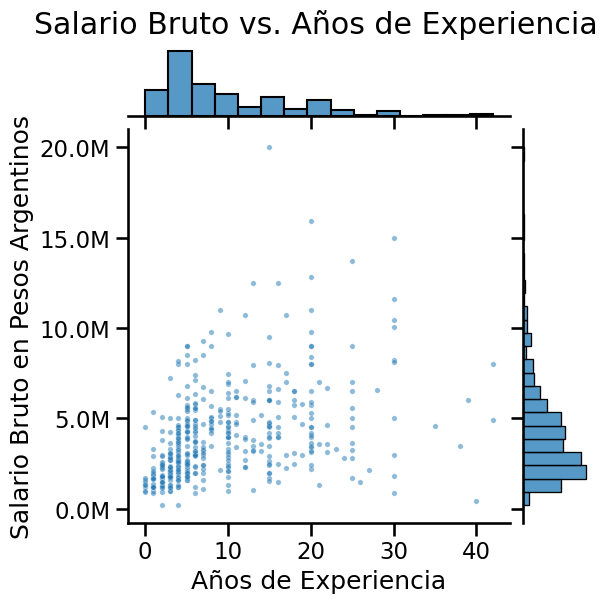

In [ ]:
df_muestra = df.sample(frac=0.1, random_state=42)

g = seaborn.jointplot(
    data=df_muestra,
    x='anos_de_experiencia',
    y='salario_bruto',
    alpha=0.5, # alpha controla la transparencia de los puntos por si hay superposiciones. Los valores varian entre 0 (completamente transparente) u 1(completamente opaco)
    joint_kws={'s': 15}, # Parámetros adicionales para el gráfico principal. En este caso "s" controla el tamaño de los puntos
)
g.ax_joint.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M')) # Formato
g.ax_joint.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}')) #Formato
g.ax_joint.set_xlabel('Años de Experiencia') # Eje X
g.ax_joint.set_ylabel('Salario Bruto en Pesos Argentinos') # Eje Y
g.figure.suptitle('Salario Bruto vs. Años de Experiencia', y=1.02);

Veamos ahora la separación por género

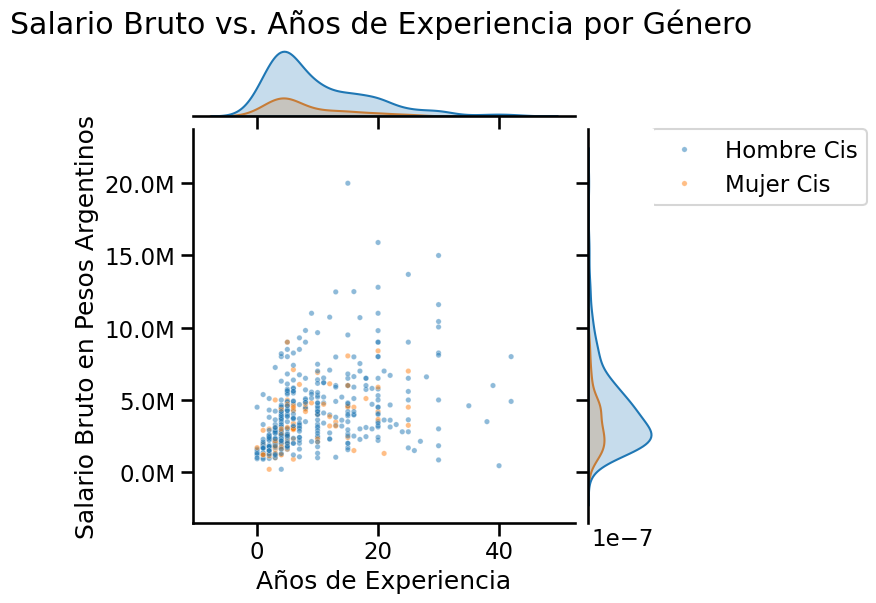

In [ ]:
df_muestra = df.sample(frac=0.1, random_state=42)

g = seaborn.jointplot(
    data=df_muestra,
    x='anos_de_experiencia',
    y='salario_bruto',
    hue='genero', #aqui agregamos el genero
    alpha=0.5,
    joint_kws={'s': 15},
)
g.ax_joint.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
g.ax_joint.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
g.ax_joint.set_xlabel('Años de Experiencia')
g.ax_joint.set_ylabel('Salario Bruto en Pesos Argentinos')
g.ax_joint.legend(loc='upper left', bbox_to_anchor=(1.2, 1), borderaxespad=0)  # Poner la leyenda fuera del grafico
g.figure.suptitle('Salario Bruto vs. Años de Experiencia por Género', y=1.02);

Dado el alto nivel de dispersión de los puntos en el gráfico, es difícil determinar a simple vista si existe una relación entre los años de experiencia y el salario bruto. Para ayudarnos a identificar esta tendencia, podemos recurrir a la regresión lineal, que ajusta una recta que minimiza la distancia entre ella y todos los puntos del gráfico. Esta recta de tendencia nos permite ver de forma resumida si la relación entre ambas variables es positiva (a más experiencia, mayor salario), negativa, o si prácticamente no existe relación. En nuestro caso graficamos una línea por género, lo que nos permite comparar si esa tendencia es similar o diferente entre hombres y mujeres. La regresión es una herramienta fundamental en el análisis de datos y la veremos en profundidad en una clase posterior; por ahora nos alcanza con interpretarla visualmente como una línea que resume la tendencia general de los datos.

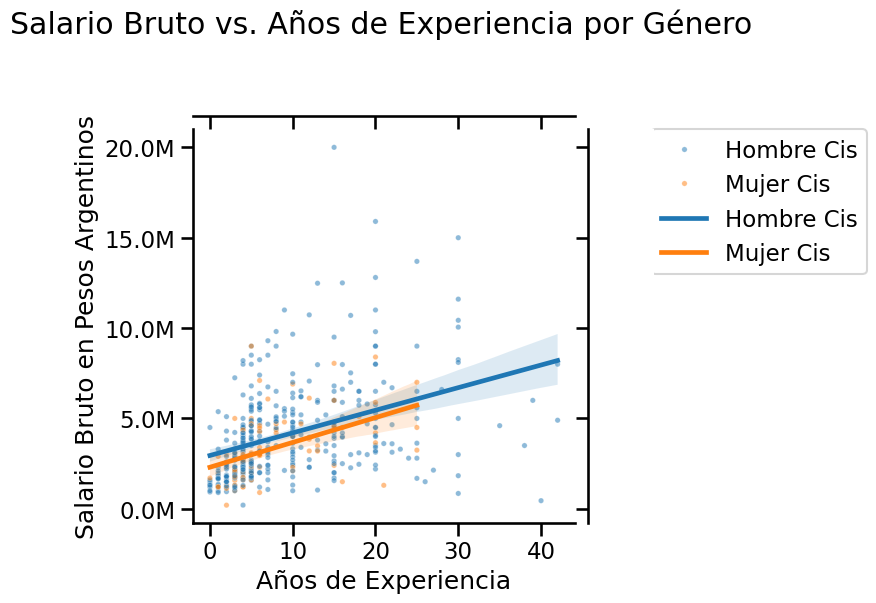

In [ ]:
df_muestra = df.sample(frac=0.1, random_state=42)

g = seaborn.JointGrid(data=df_muestra, x='anos_de_experiencia', y='salario_bruto')
g.plot_joint(seaborn.scatterplot, hue=df_muestra['genero'], alpha=0.5, s=15)

# Agregar linea de regresion por genero
for genero, grupo in df_muestra.groupby('genero'):
    seaborn.regplot(data=grupo, x='anos_de_experiencia', y='salario_bruto',
                    scatter=False, ax=g.ax_joint, label=genero)

g.ax_joint.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1_000_000:.1f}M'))
g.ax_joint.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
g.ax_joint.set_xlabel('Años de Experiencia')
g.ax_joint.set_ylabel('Salario Bruto en Pesos Argentinos')
g.ax_joint.legend(loc='upper left', bbox_to_anchor=(1.2, 1), borderaxespad=0)  # Poner la leyenda fuera del grafico
g.figure.suptitle('Salario Bruto vs. Años de Experiencia por Género', y=1.02);